# Módulo Deep Learning
## Actividad 2: Reinforcement Learning: **Frozen lake problem**

- Luis Coronel Hidalgo
- Juan Pablo Feijoo
- Jose Cantos
- Pedro Pitarch Oltra

# Enunciado: Actividad Reinforcement Learning

Resolver el problema del Frozen lake de OpenAI Gym. Documentación: https://www.gymlibrary.dev/environments/toy_text/frozen_lake/

## Objetivos
- Conseguir movermos aleatoriamente hasta cumplir el objetivo
- Conseguir que el agente aprenda con Q-learning
- (Opcional) Probar con otros hiperparámetros
- (Opcional) Modificar la recompensa

## Consideraciones
- No hay penalizaciones
- Si el agente cae en un "hole", entonces done = True y se queda atascado sin poder salir (al igual que ocurre cuando llega al "goal")

## Normas a seguir

- Se debe entregar un **ÚNICO GOOGLE COLAB notebook** (archivo .ipynb) que incluya las instrucciones presentes y su **EJECUCIÓN!!!**.
- Poner el nombre del grupo en el nombre del archivo y el nombre de todos los integrantes del grupo al inicio del notebook.

## Criterio de evaluación

- Seguimiento de las normas establecidas en la actividad.
- Corrección en el uso de algoritmos, modelos y formas idiomáticas en Python.
- El código debe poder ejecutarse sin modificación alguna en Google Colaboratory. -->

Action Space

The agent takes a 1-element vector for actions. The action space is (dir), where dir decides direction to move in which can be:

    0: LEFT

    1: DOWN

    2: RIGHT

    3: UP

## **Instalamos librerías**

In [14]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output

# **1. Definición del entorno**

Reward schedule:

    Reach goal(G): +1

    Reach hole(H): 0

    Reach frozen(F): 0

In [15]:
env = gym.make('FrozenLake-v1', map_name="4x4", is_slippery="False", render_mode="ansi")

In [16]:
obs, info = env.reset()
done = False

In [17]:
print(env.render())


SFFF
FHFH
FFFH
HFFG



# 2. Definición de hiperparámetros

Definimos el total de estados y acciones del entorno en variables independientes para que, en caso de haber un entorno aleatorio, se pueda trabajar.

In [18]:
learning_rate_a = 0.9 # alpha or learning rate
discount_factor_g = 0.9 # gamma or discount rate. Near 0: more weight/reward placed on immediate state. Near 1: more on future state.
epsilon = 1         # 1 = 100% random actions
epsilon_decay_rate = 0.0001        # epsilon decay rate. 1/0.0001 = 10,000
rng = np.random.default_rng()   # random number generator
episodes = 15000

In [19]:
Q = np.zeros((env.observation_space.n, env.action_space.n))

In [20]:
rewards_per_episode = np.zeros(episodes)

# 3. Entrenamiento

In [21]:
for episode in range(episodes):
  state = env.reset()[0]
  terminated = False
  truncated = False

  while(not terminated and not truncated):
    if rng.random() < epsilon:
      action = env.action_space.sample()
    else:
      action = np.argmax(Q[state, :])

    new_state, reward, terminated, truncated, info = env.step(action)

    Q[state,action] = Q[state,action] + learning_rate_a * (
                    reward + discount_factor_g * np.max(Q[new_state,:]) - Q[state,action]
                )
    state = new_state
    if terminated or truncated:
      break
  
  epsilon = max(epsilon - epsilon_decay_rate, 0)

  if(epsilon==0):
    learning_rate_a = 0.00001

  if reward == 1:
      rewards_per_episode[episode] = 1

  # Clear_output(wait=True)  # Limpia la salida anterior comentado por exceso de tiempo de ejecución
  # print(env.render())      # Renderiza el nuevo estado, descomentar para ver la ejecución
  if episode % 1000 == 0:
    print(f"Episodio número: {episode}.")
    print(f"Total de veces llegado a la meta: {sum(rewards_per_episode)}.")
    print(f"Valor de epsilon: {epsilon}")
  # time.sleep(0.5) # Descomentar si se quiere ver el resultado poco a poco

Episodio número: 0.
Total de veces llegado a la meta: 0.0.
Valor de epsilon: 0.9999
Episodio número: 1000.
Total de veces llegado a la meta: 15.0.
Valor de epsilon: 0.899900000000011
Episodio número: 2000.
Total de veces llegado a la meta: 26.0.
Valor de epsilon: 0.799900000000022
Episodio número: 3000.
Total de veces llegado a la meta: 40.0.
Valor de epsilon: 0.699900000000033
Episodio número: 4000.
Total de veces llegado a la meta: 65.0.
Valor de epsilon: 0.5999000000000441
Episodio número: 5000.
Total de veces llegado a la meta: 93.0.
Valor de epsilon: 0.4999000000000551
Episodio número: 6000.
Total de veces llegado a la meta: 119.0.
Valor de epsilon: 0.3999000000000661
Episodio número: 7000.
Total de veces llegado a la meta: 157.0.
Valor de epsilon: 0.2999000000000771
Episodio número: 8000.
Total de veces llegado a la meta: 219.0.
Valor de epsilon: 0.19990000000008812
Episodio número: 9000.
Total de veces llegado a la meta: 316.0.
Valor de epsilon: 0.09990000000009565
Episodio núme

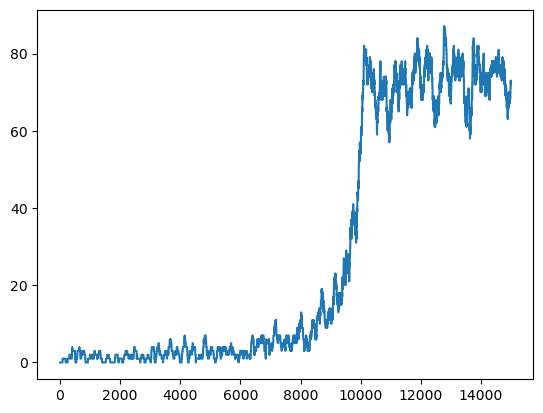

In [22]:
sum_rewards = np.zeros(episodes)
for t in range(episodes):
  sum_rewards[t] = np.sum(rewards_per_episode[max(0, t-100):(t+1)])
plt.plot(sum_rewards)

In [23]:
print(Q)

[[1.66447475e-02 1.90289625e-03 3.81760344e-03 5.09764574e-03]
 [1.82754795e-05 1.94387901e-04 1.41638590e-03 3.50405897e-02]
 [8.01972393e-03 6.45136290e-04 7.56215649e-04 7.96403928e-04]
 [2.34747042e-04 1.93302311e-04 5.20280705e-05 1.87864837e-02]
 [1.41887154e-02 1.46626136e-03 7.53411245e-04 8.47676817e-04]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [2.08426638e-04 1.35860883e-07 9.16848628e-08 2.56389877e-07]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [8.93702567e-03 2.88019250e-04 7.02161935e-05 3.88945818e-02]
 [2.69729745e-03 5.04898485e-02 4.02042296e-04 6.51052841e-04]
 [2.50547411e-02 1.92343138e-04 8.78206610e-05 2.69452608e-04]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.48324736e-02 5.99516090e-03 8.75888555e-02 5.56143490e-03]
 [9.61942192e-03 8.76218059e-01 5.32853507e-02 4.55815459e-02]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.000000

# 4. Comprobación del modelo

In [24]:
episodes = 1
rewards_per_episode = np.zeros(episodes)

In [25]:
for episode in range(episodes):
  state = env.reset()[0]
  terminated = False
  truncated = False

  while(not terminated and not truncated):

    action = np.argmax(Q[state, :])
    
    new_state, reward, terminated, truncated, info = env.step(action)

    state = new_state

    clear_output(wait=True)  # Limpia la salida anterior
    print(env.render())      # Renderiza el nuevo estado
    print(f"Episodio número: {episode}.")
    print(f"Total de veces llegado a la meta: {sum(rewards_per_episode)}.")
    time.sleep(0.5)

    if terminated or truncated:
      break

  (Down)
SFFF
FHFH
FFFH
HFFG

Episodio número: 0.
Total de veces llegado a la meta: 0.0.
